# Packages

In [2]:
import numpy as np
import matplotlib.pyplot as plt

import pandas as pd
import geopandas as gpd

from mpl_toolkits.mplot3d import Axes3D

import gempy as gp
import gempy_viewer as gpv
import gempy_engine

from gempy_engine.core.data.stack_relation_type import StackRelationType
import HelperMethods

import threading
import pickle
import os

BASE_DIR = os.getcwd()
data_dir = os.path.join(BASE_DIR, '..', 'Data', 'Tharsis AOI 1')

trigger_create_cross_section = True

Setting Backend To: AvailableBackends.numpy


# Model Parameters

In [3]:
# Model Extent
min_x = -707522
max_x = -677518
min_y =  4528453
max_y =  4549947
max_z =  505
model_depth = -500

# Set the extent of the model
extent=[min_x, max_x, max_y, min_y, model_depth, max_z]

# Set model resolution
nx = ny = nz = 64  # Define grid resolution
resolution = [nx, ny, nz]

# Topography
path_to_topography_reduced = os.path.join(data_dir, 'topo_reduced_sf0.1.tif')

# Load in and Visualise Data

In [4]:
plutonite_orientations_df = pd.read_csv("sampled_orientationinputpoints10_perfect.csv")
plutonite_points_df       = pd.read_csv("sampled_formationinputpoints10_perfect.csv")

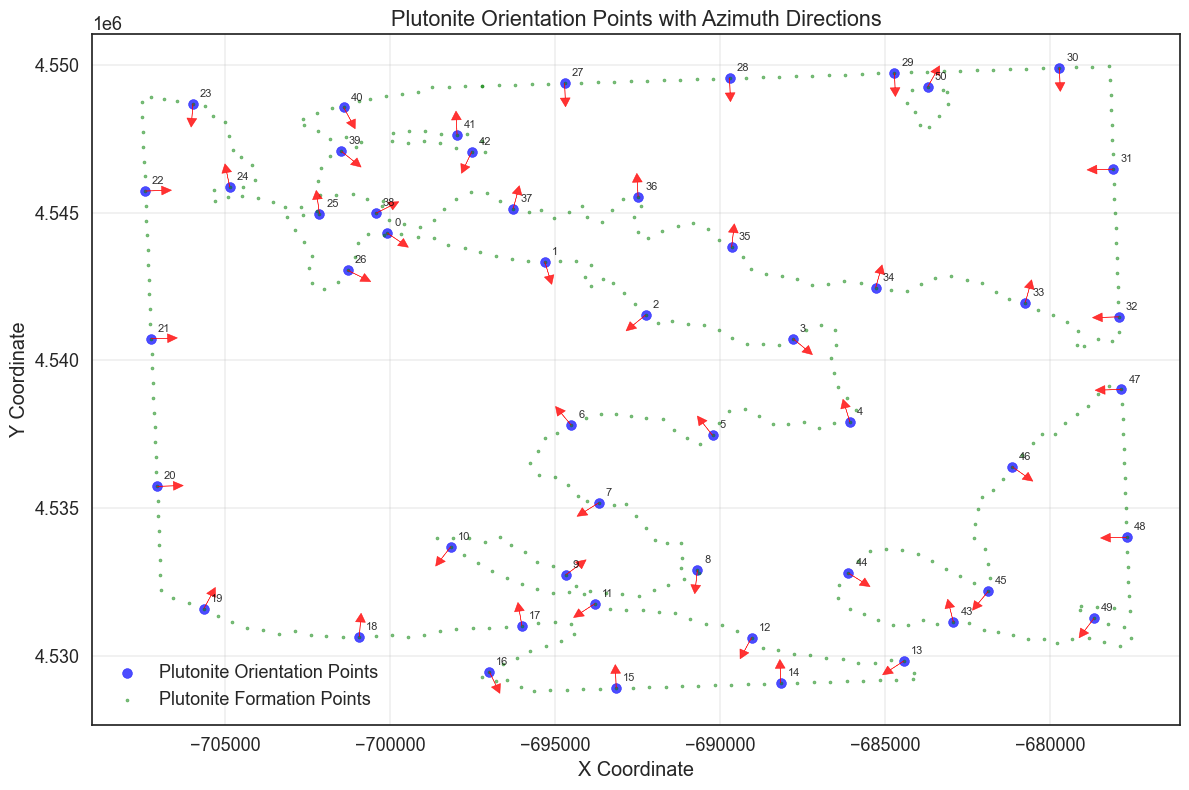

In [5]:
# Visualize plutonite orientations on a map
fig, ax = plt.subplots(figsize=(12, 8))

# Plot the orientation points
scatter = ax.scatter(plutonite_orientations_df['X'], plutonite_orientations_df['Y'], 
                    c='blue', s=50, alpha=0.7, label='Plutonite Orientation Points')

# Also plot the formation points
scatter2 = ax.scatter(plutonite_points_df['X'], plutonite_points_df['Y'], 
                        c='green', s=20, alpha=0.5, label='Plutonite Formation Points', marker='.')

# Add arrows for azimuth directions
for idx, row in plutonite_orientations_df.iterrows():
    # Arrow parameters
    arrow_length = 500  # arrow length in map units
    azimuth_rad = np.deg2rad(row['azimuth'])  # Convert azimuth to radians
    dx = arrow_length * np.sin(azimuth_rad)
    dy = arrow_length * np.cos(azimuth_rad)
    
    # Draw arrow showing strike direction
    ax.arrow(row['X'], row['Y'], dx, dy, 
            head_width=300, head_length=300, fc='red', ec='red', alpha=0.8)

# Add annotations for each point showing its index number
for idx, row in plutonite_orientations_df.iterrows():
    ax.annotate(str(idx), (row['X'], row['Y']), 
                xytext=(5, 5), textcoords='offset points',
                fontsize=8, alpha=0.8, color='black')

ax.set_xlabel('X Coordinate')
ax.set_ylabel('Y Coordinate')
ax.set_title('Plutonite Orientation Points with Azimuth Directions')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Grid Search Plutonite Model Perturbations

In [13]:
# Grid search over different amounts of sampling and dip angle assignment

# level_of_sampling_points = np.array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]) # removing 90%, 80%, 70% etc...
# level_of_sampling_orientations = np.array([0.7, 0.8, 0.9, 1.0]) # removing 90%, 80%, 70% etc...
# methods_of_assigning_dip_angles = {"purely random": 1, "mildly random": 2, "little random": 3} # how do we assign dip angles to measurement points

level_of_sampling_points = np.array([0.9, 0.8, 0.7, 0.6, 0.5]) # removing 90%, 80%, 70% etc...
level_of_sampling_orientations = np.array([0.9, 0.8, 0.7]) # removing 90%, 80%, 70% etc...
methods_of_assigning_dip_angles = {"purely random": 1, "mildly random": 2, "little random": 3} # how do we assign dip angles to measurement points

# Cross Sections of Interest

In [14]:
# Set cross sections
section_dict = {'W-E_1': ([-710000,4.54750*1e6], [-675000,4.54750*1e6], [64,64]),
                'W-E_2': ([-710000,4.54000*1e6], [-675000,4.54000*1e6], [64,64]),
                'W-E_3': ([-710000,4.53500*1e6], [-675000,4.53500*1e6], [64,64]),
                'W-E_4': ([-710000,4.5325*1e6], [-675000,4.5325*1e6], [64,64]),
                
                'N-S_1': ([-707500,4.530*1e6], [-707500,4.550*1e6], [64,64]),
                'N-S_2': ([-697500,4.530*1e6], [-697500,4.550*1e6], [64,64]),
                'N-S_3': ([-690000,4.530*1e6], [-690000,4.550*1e6], [64,64]),
                'N-S_4': ([-682500,4.530*1e6], [-682500,4.550*1e6], [64,64])}

# Creating Folder Structure for saving Perturbation Images

In [15]:

# Create main results folder and subfolder structure before loops
main_results_folder = "Perturbation Results"
if not os.path.exists(main_results_folder):
    os.makedirs(main_results_folder)

# Create subfolder structure for all combinations
for sampling in level_of_sampling_points:
    sampling_folder = os.path.join(main_results_folder, f"Sampling_Points_{int(sampling*100)}pct")
    if not os.path.exists(sampling_folder):
        os.makedirs(sampling_folder)
    
    for orientations in level_of_sampling_orientations:
        orientations_folder = os.path.join(sampling_folder, f"Sampling_Orientations_{int(orientations*100)}pct")
        if not os.path.exists(orientations_folder):
            os.makedirs(orientations_folder)

print(f"Main folder: {main_results_folder}")

Main folder: Perturbation Results


# Calculating Perturbation Results

Add button to skip the combinations we already did

Indices 0-26:
Indices 27-40:
Indices 41-42:
Indices 50:
Indices 43-49:

In [16]:
# Loop over all combinations of level_of_sampling and methods_of_assigning_dip_angles
for sampling in level_of_sampling_points:
    for orientations in level_of_sampling_orientations:
        for method_name, method_value in methods_of_assigning_dip_angles.items():

            # Create a descriptive string for the current parameter combination
            param_combination = f"Sampling Points: {sampling}, Sampling Orientations: {orientations}, Method: {method_name} (value: {method_value})"

            # Load the data
            plutonite_orientations_df = pd.read_csv("sampled_orientationinputpoints10_perfect.csv")
            plutonite_points_df       = pd.read_csv("sampled_formationinputpoints10_perfect.csv")

            # Make a copy of the orientations DataFrame
            plutonite_orientations_df = plutonite_orientations_df.copy()
            
            # Assign dip angles based on the chosen method
            if method_name == "purely random":
                # Very random
                std = 5
                plutonite_orientations_df.loc[0:26,  'dip']    = np.random.normal(80, std, size=27)     # indices 0 to 26
                plutonite_orientations_df.loc[27:40, 'dip']    = np.random.normal(60, std, size=14)     # indices 27 to 40
                plutonite_orientations_df.loc[41:42, 'dip']    = np.random.normal(60, std, size=2)      # indices 41 to 42
                plutonite_orientations_df.loc[43:49, 'dip']    = np.random.normal(40, std, size=7)      # indices 43 to 49
                plutonite_orientations_df.loc[50,    'dip']    = np.random.normal(60, std, size=1)      # index 50 only
            elif method_name == "mildly random":
                # Midly random
                std = 2.5
                plutonite_orientations_df.loc[0:26,  'dip']    = np.random.normal(80, std, size=27)     # indices 0 to 26
                plutonite_orientations_df.loc[27:40, 'dip']    = np.random.normal(60, std, size=14)     # indices 27 to 40
                plutonite_orientations_df.loc[41:42, 'dip']    = np.random.normal(60, std, size=2)      # indices 41 to 42
                plutonite_orientations_df.loc[43:49, 'dip']    = np.random.normal(40, std, size=7)      # indices 43 to 49
                plutonite_orientations_df.loc[50,    'dip']    = np.random.normal(60, std, size=1)      # index 50 only
            elif method_name == "little random":
                # Little random
                std = 1
                plutonite_orientations_df.loc[0:26,  'dip']    = np.random.normal(80, std, size=27)     # indices 0 to 26
                plutonite_orientations_df.loc[27:40, 'dip']    = np.random.normal(60, std, size=14)     # indices 27 to 40
                plutonite_orientations_df.loc[41:42, 'dip']    = np.random.normal(60, std, size=2)      # indices 41 to 42
                plutonite_orientations_df.loc[43:49, 'dip']    = np.random.normal(40, std, size=7)      # indices 43 to 49
                plutonite_orientations_df.loc[50,    'dip']    = np.random.normal(60, std, size=1)      # index 50 only

            
            # Clip the values to ensure they're between 0 and 90
            plutonite_orientations_df['dip'] = np.clip(plutonite_orientations_df['dip'], 0, 90)


            # Calculate number of data points to sample
            num_points_to_sample_points = int(len(plutonite_orientations_df) * sampling)
            num_points_to_sample_orientations = int(len(plutonite_points_df) * orientations)

            # Sample the data based on the current sampling level without random state set (!)
            sampled_orientations_df = plutonite_orientations_df.sample(n=num_points_to_sample_points).reset_index(drop=True)
            sampled_points_df = plutonite_points_df.sample(n=num_points_to_sample_orientations).reset_index(drop=True)
            print(f"Processing: Sampling level (points) = {sampling}, Sampling level (orientations) = {orientations}, Method = {method_name} (value: {method_value})")

            # Save the sampled data to temporary CSV files
            sampled_orientations_path = "temp_sampled_orientationinputpoints.csv"
            sampled_points_path = "temp_sampled_formationinputpoints.csv"
            sampled_orientations_df.to_csv(sampled_orientations_path, index=False)
            sampled_points_df.to_csv(sampled_points_path, index=False)

            # Create geological model
            plutonite_geo_model = gp.create_geomodel(
                project_name='AOI',
                extent=extent,
                # refinement=6,
                resolution=resolution,
                importer_helper=gp.data.ImporterHelper(
                    path_to_orientations=os.path.join(BASE_DIR,   "temp_sampled_orientationinputpoints.csv"),
                    path_to_surface_points=os.path.join(BASE_DIR, "temp_sampled_formationinputpoints.csv"),
                )
            )
            
            # Set layers
            gp.map_stack_to_surfaces(
                gempy_model=plutonite_geo_model,
                mapping_object={
                    "Tournaisian_Plutonites": ["Tournaisian Plutonites"],
                }
            )

            # Set topography
            gp.set_topography_from_file(grid=plutonite_geo_model.grid, filepath=path_to_topography_reduced)

            # Set cross sections
            gp.set_section_grid(plutonite_geo_model.grid, section_dict)
            
            # Compute plutonite model
            plutonite_model = gp.compute_model(plutonite_geo_model)

            # Define the target subfolder for this iteration
            target_folder = os.path.join(main_results_folder, 
                                       f"Sampling_Points_{int(sampling*100)}pct",
                                       f"Sampling_Orientations_{int(orientations*100)}pct")

            # Create image filename with path to target folder
            image_filename = os.path.join(target_folder, 
                                        f"plutonite_model_sampling_points_{int(sampling*100)}pct_sampling_orientations_{int(orientations*100)}pct_method_{method_name.replace(' ', '_')}.png")
            
            # Create image filenames for cross sections
            W_E_cross_section_filename = os.path.join(target_folder, 
                                        f"W_E_plutonite_model_cross_sections_sampling_points_{int(sampling*100)}pct_sampling_orientations_{int(orientations*100)}pct_method_{method_name.replace(' ', '_')}.png")
            N_S_cross_section_filename = os.path.join(target_folder, 
                                        f"N_S_plutonite_model_cross_sections_sampling_points_{int(sampling*100)}pct_sampling_orientations_{int(orientations*100)}pct_method_{method_name.replace(' ', '_')}.png")

            # Visualise results from above and display parameter combination
            plutonite_lith_block = plutonite_geo_model.solutions.raw_arrays.lith_block
            plutonite_lith_block_reshaped = plutonite_lith_block.reshape(64,64,64)
            plutonite_id = 1
            plutonite_mask = plutonite_lith_block_reshaped == plutonite_id
            plutonite_count_2d = np.sum(plutonite_mask, axis=2)
            plutonite_count_2d_masked = np.ma.masked_where(plutonite_count_2d == 0, plutonite_count_2d)
            
            # Create the 2D plot using imshow with masked zeros
            fig, ax = plt.subplots(figsize=(12, 10))

            # Use imshow for a pixel-based representation with masked zeros
            im = ax.imshow(plutonite_count_2d_masked.T, 
                        extent=[min_x/1000, max_x/1000, min_y/1000, max_y/1000], 
                        cmap='plasma', 
                        origin='lower', 
                        interpolation='nearest', 
                        alpha=0.9)

            # Add colorbar
            cbar = plt.colorbar(im, ax=ax, shrink=0.8)
            cbar.set_label('Number of Plutonite Voxels in Vertical Stack', fontsize=12)

            # Set labels and title
            ax.set_xlabel('X Coordinate (km)', fontsize=12)
            ax.set_ylabel('Y Coordinate (km)', fontsize=12)
            ax.set_title(f'Plutonite Thickness\n{param_combination}', fontsize=14, pad=20)

            # Set aspect ratio to be equal
            ax.set_aspect('equal')

            # Add grid
            ax.grid(True, alpha=0.3, linestyle='--', color='black')

            # draw cross section lines
            for section_name, (start, end, res) in section_dict.items():
                ax.plot([start[0]/1000, end[0]/1000], [start[1]/1000, end[1]/1000], 
                        color='red', linestyle='--', linewidth=1.5, alpha=0.8)
                mid_x = (start[0] + end[0]) / 2000
                mid_y = (start[1] + end[1]) / 2000
                ax.text(mid_x, mid_y, section_name, color='white', fontsize=7, ha='center', va='center', backgroundcolor='black', alpha=0.7)
            
            plt.tight_layout()

            # Save the image to the appropriate subfolder
            fig.savefig(image_filename, dpi=300, bbox_inches='tight')
            plt.close()
            print(f"Saved image: {image_filename}")

            # Create cross sections
            gpv.plot_2d(plutonite_geo_model, section_names=['W-E_1','W-E_2','W-E_3','W-E_4'], ve=15)
            # save the image
            plt.savefig(W_E_cross_section_filename, dpi=300, bbox_inches='tight')
            plt.close()

            gpv.plot_2d(plutonite_geo_model, section_names=['N-S_1','N-S_2','N-S_3','N-S_4'], ve=15)
            # save the image
            plt.savefig(N_S_cross_section_filename, dpi=300, bbox_inches='tight')
            plt.close()
            
            # Delete temporary CSV files
            if os.path.exists(sampled_orientations_path):
                os.remove(sampled_orientations_path)
            if os.path.exists(sampled_points_path):
                os.remove(sampled_points_path)

            # Display progress
            model_number = (list(level_of_sampling_points).index(sampling) * len(level_of_sampling_orientations) * len(methods_of_assigning_dip_angles)) + (list(level_of_sampling_orientations).index(orientations) * len(methods_of_assigning_dip_angles)) + list(methods_of_assigning_dip_angles.keys()).index(method_name) + 1
            total_models = len(level_of_sampling_points) * len(level_of_sampling_orientations) * len(methods_of_assigning_dip_angles)
            print(f"Completed model number {model_number} of {total_models}")

gpv.plot_section_traces(plutonite_geo_model)
print("\nAll perturbation results have been saved to organized subfolders!")

Processing: Sampling level (points) = 0.9, Sampling level (orientations) = 0.9, Method = purely random (value: 1)
Active grids: GridTypes.NONE|TOPOGRAPHY|DENSE
Active grids: GridTypes.NONE|SECTIONS|TOPOGRAPHY|DENSE
Setting Backend To: AvailableBackends.numpy
Chunking done: 372 chunks


c:\Users\mrcon\miniconda3\envs\myenv\lib\site-packages\gempy_engine\modules\activator\_soft_segment.py:95: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + bt.t.exp(x))


Chunking done: 6 chunks
Chunking done: 31 chunks
Chunking done: 11 chunks
Saved image: Perturbation Results\Sampling_Points_90pct\Sampling_Orientations_90pct\plutonite_model_sampling_points_90pct_sampling_orientations_90pct_method_purely_random.png


c:\Users\mrcon\miniconda3\envs\myenv\lib\site-packages\gempy_viewer\API\_plot_2d_sections_api.py:106: UserWarning: Section contacts not implemented yet. We need to pass scalar field for the sections grid
  warnings.warn(
c:\Users\mrcon\miniconda3\envs\myenv\lib\site-packages\gempy_viewer\API\_plot_2d_API.py:176: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  p.fig.show()
c:\Users\mrcon\miniconda3\envs\myenv\lib\site-packages\gempy_viewer\API\_plot_2d_sections_api.py:106: UserWarning: Section contacts not implemented yet. We need to pass scalar field for the sections grid
  warnings.warn(
c:\Users\mrcon\miniconda3\envs\myenv\lib\site-packages\gempy_viewer\API\_plot_2d_API.py:176: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  p.fig.show()


Completed model number 1 of 45
Processing: Sampling level (points) = 0.9, Sampling level (orientations) = 0.9, Method = mildly random (value: 2)
Active grids: GridTypes.NONE|TOPOGRAPHY|DENSE
Active grids: GridTypes.NONE|SECTIONS|TOPOGRAPHY|DENSE
Setting Backend To: AvailableBackends.numpy
Chunking done: 372 chunks


...

c:\Users\mrcon\miniconda3\envs\myenv\lib\site-packages\gempy_engine\modules\activator\_soft_segment.py:95: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + bt.t.exp(x))


Chunking done: 26 chunks
Chunking done: 9 chunks
Saved image: Perturbation Results\Sampling_Points_80pct\Sampling_Orientations_70pct\plutonite_model_sampling_points_80pct_sampling_orientations_70pct_method_purely_random.png


c:\Users\mrcon\miniconda3\envs\myenv\lib\site-packages\gempy_viewer\API\_plot_2d_sections_api.py:106: UserWarning: Section contacts not implemented yet. We need to pass scalar field for the sections grid
  warnings.warn(
c:\Users\mrcon\miniconda3\envs\myenv\lib\site-packages\gempy_viewer\API\_plot_2d_API.py:176: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  p.fig.show()
c:\Users\mrcon\miniconda3\envs\myenv\lib\site-packages\gempy_viewer\API\_plot_2d_sections_api.py:106: UserWarning: Section contacts not implemented yet. We need to pass scalar field for the sections grid
  warnings.warn(
c:\Users\mrcon\miniconda3\envs\myenv\lib\site-packages\gempy_viewer\API\_plot_2d_API.py:176: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  p.fig.show()


Completed model number 16 of 45
Processing: Sampling level (points) = 0.8, Sampling level (orientations) = 0.7, Method = mildly random (value: 2)
Active grids: GridTypes.NONE|TOPOGRAPHY|DENSE
Active grids: GridTypes.NONE|SECTIONS|TOPOGRAPHY|DENSE
Setting Backend To: AvailableBackends.numpy


KeyboardInterrupt: 

In [10]:
plutonite_orientations_df = pd.read_csv("sampled_orientationinputpoints10_perfect.csv")
# Make a copy of the orientations DataFrame
plutonite_orientations_df = plutonite_orientations_df.copy()

method_name = "mildly random"

# Assign dip angles based on the chosen method
if method_name == "purely random":
    # Very random
    std = 5
    plutonite_orientations_df.loc[0:26,  'dip']    = np.random.normal(80, std, size=27)     # indices 0 to 26
    plutonite_orientations_df.loc[27:40, 'dip']    = np.random.normal(60, std, size=14)     # indices 27 to 40
    plutonite_orientations_df.loc[41:42, 'dip']    = np.random.normal(60, std, size=2)      # indices 41 to 42
    plutonite_orientations_df.loc[43:49, 'dip']    = np.random.normal(40, std, size=7)      # indices 43 to 49
    plutonite_orientations_df.loc[50,    'dip']    = np.random.normal(60, std, size=1)      # index 50 only
elif method_name == "mildly random":
    # Midly random
    std = 2.5
    plutonite_orientations_df.loc[0:26,  'dip']    = np.random.normal(80, std, size=27)     # indices 0 to 26
    plutonite_orientations_df.loc[27:40, 'dip']    = np.random.normal(60, std, size=14)     # indices 27 to 40
    plutonite_orientations_df.loc[41:42, 'dip']    = np.random.normal(60, std, size=2)      # indices 41 to 42
    plutonite_orientations_df.loc[43:49, 'dip']    = np.random.normal(40, std, size=7)      # indices 43 to 49
    plutonite_orientations_df.loc[50,    'dip']    = np.random.normal(60, std, size=1)      # index 50 only
elif method_name == "little random":
    # Little random
    std = 1
    plutonite_orientations_df.loc[0:26,  'dip']    = np.random.normal(80, std, size=27)     # indices 0 to 26
    plutonite_orientations_df.loc[27:40, 'dip']    = np.random.normal(60, std, size=14)     # indices 27 to 40
    plutonite_orientations_df.loc[41:42, 'dip']    = np.random.normal(60, std, size=2)      # indices 41 to 42
    plutonite_orientations_df.loc[43:49, 'dip']    = np.random.normal(40, std, size=7)      # indices 43 to 49
    plutonite_orientations_df.loc[50,    'dip']    = np.random.normal(60, std, size=1)      # index 50 only


# Clip the values to ensure they're between 0 and 90
plutonite_orientations_df['dip'] = np.clip(plutonite_orientations_df['dip'], 0, 90)

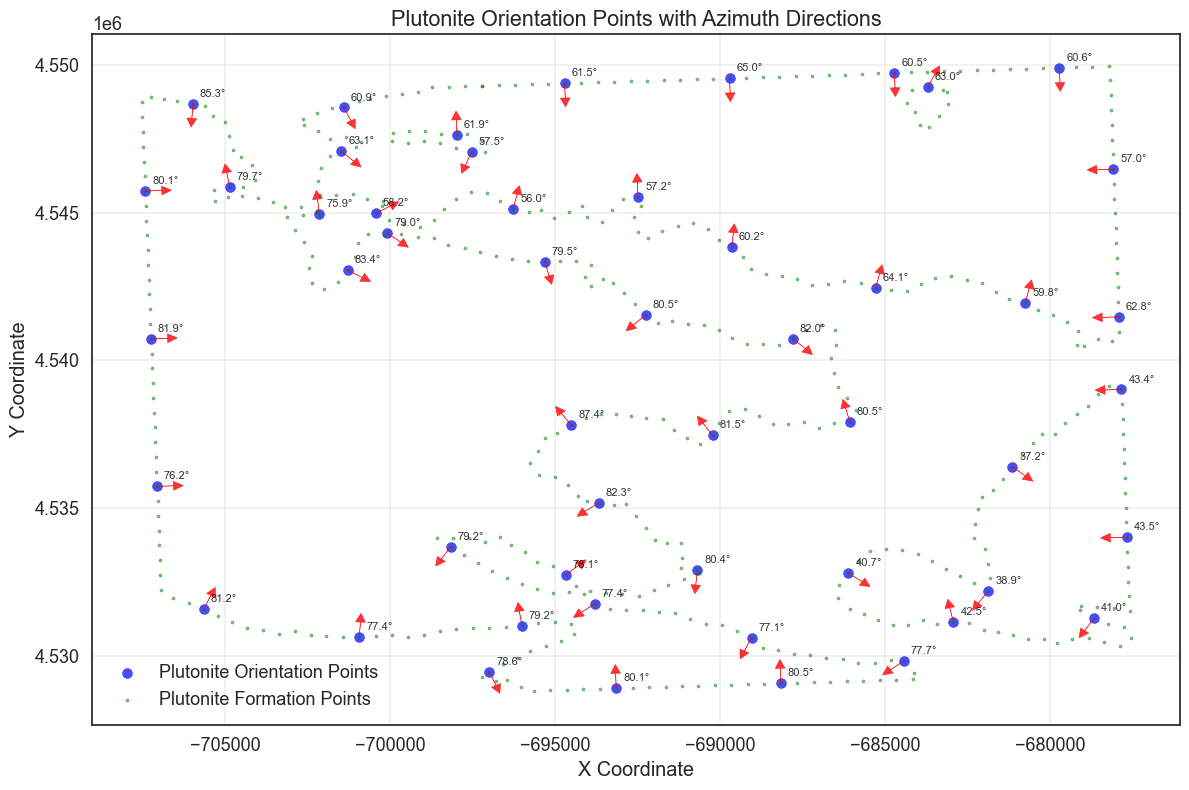

In [11]:

# Visualize plutonite orientations on a map
fig, ax = plt.subplots(figsize=(12, 8))

# Plot the orientation points
scatter = ax.scatter(plutonite_orientations_df['X'], plutonite_orientations_df['Y'], 
                    c='blue', s=50, alpha=0.7, label='Plutonite Orientation Points')

# Also plot the formation points
scatter2 = ax.scatter(plutonite_points_df['X'], plutonite_points_df['Y'], 
                        c='green', s=20, alpha=0.5, label='Plutonite Formation Points', marker='.')

# Add arrows for azimuth directions
for idx, row in plutonite_orientations_df.iterrows():
    # Arrow parameters
    arrow_length = 500  # arrow length in map units
    azimuth_rad = np.deg2rad(row['azimuth'])  # Convert azimuth to radians
    dx = arrow_length * np.sin(azimuth_rad)
    dy = arrow_length * np.cos(azimuth_rad)
    
    # Draw arrow showing strike direction
    ax.arrow(row['X'], row['Y'], dx, dy, 
            head_width=300, head_length=300, fc='red', ec='red', alpha=0.8)

# Add annotations for each point showing its dip angle
for idx, row in plutonite_orientations_df.iterrows():
    ax.annotate(f"{row['dip']:.1f}°", (row['X'], row['Y']), 
                xytext=(5, 5), textcoords='offset points',
                fontsize=8, alpha=0.8, color='black')

ax.set_xlabel('X Coordinate')
ax.set_ylabel('Y Coordinate')
ax.set_title('Plutonite Orientation Points with Azimuth Directions')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

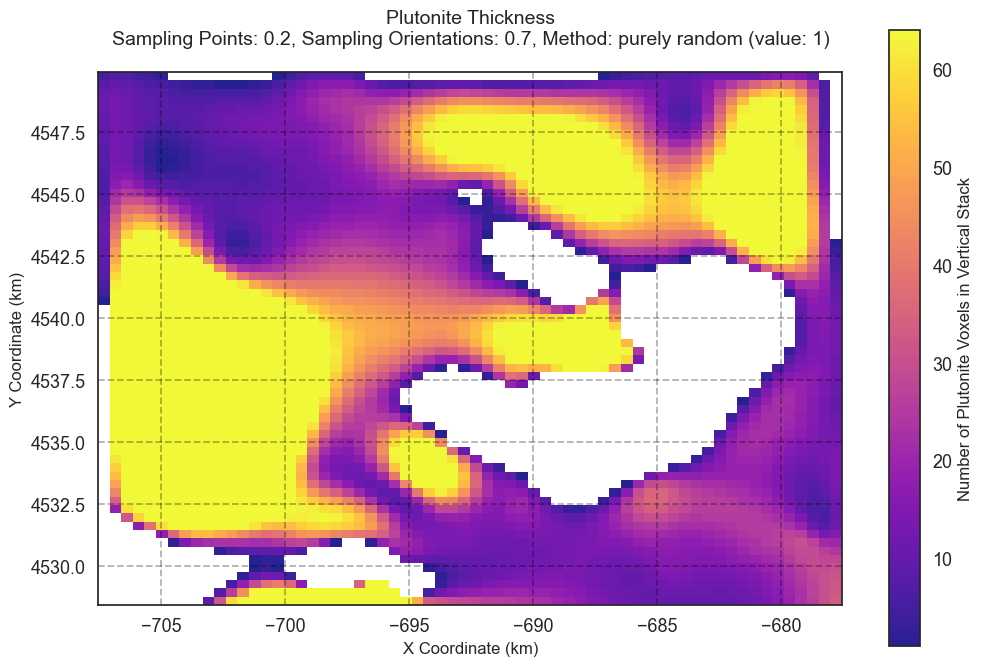

In [12]:
# Create the 2D plot using imshow with masked zeros
fig, ax = plt.subplots(figsize=(12, 10))

# Use imshow for a pixel-based representation with masked zeros
im = ax.imshow(plutonite_count_2d_masked.T, 
            extent=[min_x/1000, max_x/1000, min_y/1000, max_y/1000], 
            cmap='plasma', 
            origin='lower', 
            interpolation='nearest', 
            alpha=0.9)

# Add colorbar
cbar = plt.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label('Number of Plutonite Voxels in Vertical Stack', fontsize=12)

# Set labels and title
ax.set_xlabel('X Coordinate (km)', fontsize=12)
ax.set_ylabel('Y Coordinate (km)', fontsize=12)
ax.set_title(f'Plutonite Thickness\n{param_combination}', fontsize=14, pad=20)

# Set aspect ratio to be equal
ax.set_aspect('equal')

# Add grid
ax.grid(True, alpha=0.3, linestyle='--', color='black')